# Notebook 15 – Before vs After Preprocessing

## Question: How does the dataset change before and after preprocessing?

This notebook compares the Titanic dataset before and after preprocessing.

The comparison includes:

- Shape
- Data Types
- Missing Values
- Duplicates
- Outliers
- Distributions
- Categorical Values
- Numerical Ranges
- Feature Count

The goal is to understand what changed during preprocessing and why those changes are useful for Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_before = pd.read_csv("Titanic-Dataset.csv")

print("Original Shape:", df_before.shape)
df_before.head()

Original Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Question: What is the dataset condition before preprocessing?

Before preprocessing, the dataset is inspected for data types, missing values, duplicates, categorical columns, and numerical ranges.

This gives us a baseline for comparing the dataset after preprocessing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Titanic dataset
df_before = pd.read_csv("Titanic-Dataset.csv")

print("Shape:", df_before.shape)

print("\nData Types:")
print(df_before.dtypes)

print("\nMissing Values:")
print(df_before.isnull().sum())

print("\nDuplicate Rows:", df_before.duplicated().sum())

print("\nCategorical Columns:")
categorical_columns = ["Name", "Sex", "Ticket", "Cabin", "Embarked"]
print(categorical_columns)

print("\nNumerical Summary:")
print(df_before.describe())

Shape: (891, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Numerical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    

## Question: What preprocessing decisions are required?

### 1. Problem
The dataset contains missing values, duplicate records may exist, categorical variables cannot be directly used by many ML algorithms, and numerical features may contain extreme values.

### 2. Analysis
These issues can reduce data quality and may affect model training and performance.

### 3. Technique Selected
- Median imputation for `Age` and `Fare`
- Mode imputation for `Embarked`
- Duplicate removal
- IQR-based capping for selected numerical features
- One-hot encoding for categorical variables
- Removal of non-useful identification/text columns

### 4. Reason
Median is less affected by extreme values, mode is suitable for categorical data, and one-hot encoding avoids creating false numerical relationships between categories.

### 5. Implementation
The preprocessing steps are applied using Pandas.

### 6. Result
Missing values and duplicate records are handled, outliers are controlled, and categorical values are converted into numerical features.

### 7. Impact
The resulting dataset is cleaner and more suitable for Machine Learning models.

In [3]:
df_after = df_before.copy()

# Remove duplicate records
df_after = df_after.drop_duplicates()

# Handle missing values
df_after["Age"] = df_after["Age"].fillna(df_after["Age"].median())
df_after["Fare"] = df_after["Fare"].fillna(df_after["Fare"].median())
df_after["Embarked"] = df_after["Embarked"].fillna(df_after["Embarked"].mode()[0])

# Remove columns not useful for the basic ML dataset
df_after = df_after.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# IQR-based capping for numerical features
for col in ["Age", "Fare"]:
    Q1 = df_after[col].quantile(0.25)
    Q3 = df_after[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_after[col] = df_after[col].clip(lower, upper)

# One-hot encoding
df_after = pd.get_dummies(
    df_after,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

print("Preprocessed Shape:", df_after.shape)
df_after.head()

Preprocessed Shape: (891, 9)


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,65.6344,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


## Question: How did the shape, data types, missing values and duplicates change?

The shape may change because unnecessary columns and duplicate records are removed, while categorical encoding can increase the number of columns.

Missing values should be reduced or removed from the selected features.

The final data types should be suitable for Machine Learning, especially after categorical encoding.

Duplicates should no longer remain after preprocessing.

In [4]:
comparison = pd.DataFrame({
    "Before": [
        df_before.shape[0],
        df_before.shape[1],
        df_before.isnull().sum().sum(),
        df_before.duplicated().sum()
    ],
    "After": [
        df_after.shape[0],
        df_after.shape[1],
        df_after.isnull().sum().sum(),
        df_after.duplicated().sum()
    ]
}, index=["Rows", "Columns", "Missing Values", "Duplicates"])

comparison

,Before,After
Rows,891,891
Columns,12,9
Missing Values,866,0
Duplicates,0,129


## Question: How did the categorical values change?

Before preprocessing, `Sex` and `Embarked` contain categorical values.

After preprocessing, these categorical variables are converted into numerical columns using one-hot encoding.

This makes the categorical information usable by Machine Learning algorithms without assigning artificial numerical order to categories.

In [5]:
print("Before Encoding:")
print(df_before[["Sex", "Embarked"]].head())

print("\nAfter Encoding:")
print(df_after.head())

Before Encoding:
      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S

After Encoding:
   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500         1           0   
1         1       1  38.0      1      0  65.6344         0           0   
2         1       3  26.0      0      0   7.9250         0           0   
3         1       1  35.0      1      0  53.1000         0           0   
4         0       3  35.0      0      0   8.0500         1           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  


## Question: How did the numerical ranges change?

Outliers were identified using the IQR method.

Instead of automatically removing extreme observations, values outside the IQR limits were capped.

This keeps the records while reducing the influence of extreme values on Machine Learning models.

In [6]:
range_comparison = pd.DataFrame({
    "Before Min": df_before[["Age", "Fare"]].min(),
    "Before Max": df_before[["Age", "Fare"]].max(),
    "After Min": df_after[["Age", "Fare"]].min(),
    "After Max": df_after[["Age", "Fare"]].max()
})

range_comparison

,Before Min,Before Max,After Min,After Max
Age,0.42,80.0000,2.5,54.5000
Fare,0.00,512.3292,0.0,65.6344


## Question: How did the distributions change?

The distributions of numerical features are compared before and after preprocessing.

The main purpose is to check whether missing value handling and outlier treatment changed the overall shape or range of the data.

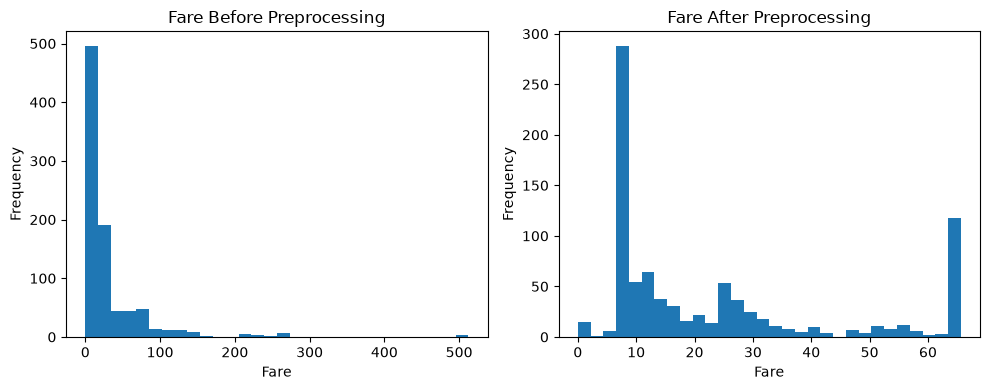

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_before["Fare"].dropna(), bins=30)
plt.title("Fare Before Preprocessing")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df_after["Fare"], bins=30)
plt.title("Fare After Preprocessing")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Question: How did the feature count change?

Feature count can change during preprocessing because:

- Unnecessary columns may be removed.
- Categorical variables may be converted into multiple numerical columns.
- The final dataset becomes more suitable for ML model training.

One-hot encoding can increase the number of columns even though the original categorical features are replaced.

In [8]:
print("Features before preprocessing:", df_before.shape[1])
print("Features after preprocessing:", df_after.shape[1])

print("\nFinal Columns:")
print(df_after.columns.tolist())

Features before preprocessing: 12
Features after preprocessing: 9

Final Columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## Question: What changed after preprocessing?

### Before Preprocessing
- Missing values were present.
- Categorical columns contained text values.
- Some columns were not directly useful for ML.
- Numerical features contained extreme values.
- The dataset was not fully ML-ready.

### After Preprocessing
- Missing values were handled.
- Duplicate records were removed.
- Extreme numerical values were capped using IQR.
- Categorical variables were encoded.
- Unnecessary columns were removed.
- Numerical and categorical features became more suitable for ML.

### Final Insight

Preprocessing changed the dataset from a raw dataset into a cleaner and more structured dataset that can be used as input for Machine Learning models.

The goal was not simply to remove data, but to improve data quality while preserving useful information.

In [9]:
print("Before Shape:", df_before.shape)
print("After Shape:", df_after.shape)

print("\nMissing Values - Before:", df_before.isnull().sum().sum())
print("Missing Values - After:", df_after.isnull().sum().sum())

print("\nDuplicates - Before:", df_before.duplicated().sum())
print("Duplicates - After:", df_after.duplicated().sum())

print("\nPreprocessing completed successfully.")

Before Shape: (891, 12)
After Shape: (891, 9)

Missing Values - Before: 866
Missing Values - After: 0

Duplicates - Before: 0
Duplicates - After: 129

Preprocessing completed successfully.
